# 📈 Урок 6: Линейная регрессия

## Что такое линейная регрессия?

**Линейная регрессия** — это алгоритм для предсказания **непрерывного числового значения** на основе одного или нескольких признаков.

### 🍎 Житейская аналогия

Представьте, что вы оцениваете квартиру:
- Базовая цена: 3 млн руб.
- +100 000 руб. за каждый м²
- +500 000 руб. за этаж выше 5-го

**Формула**: `Цена = 3 000 000 + 100 000 × м² + 500 000 × (этаж>5)`

Это и есть линейная регрессия!

## 🏢 Применение в бизнесе

| Отрасль | Задача | Выгода |
|---------|--------|--------|
| **Ритейл** | Прогноз продаж | Оптимизация запасов |
| **Недвижимость** | Оценка стоимости | Быстрые сделки |
| **Финансы** | Прогноз выручки | Планирование бюджета |
| **Логистика** | Время доставки | Довольные клиенты |

**Преимущества**: Быстрая, интерпретируемая, хорошая базовая модель

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📦 Создаём датасет: прогнозирование цен на квартиры

In [17]:
np.random.seed(42)
n = 300

area = np.random.uniform(30, 120, n)
rooms = np.random.choice([1, 2, 3, 4], n, p=[0.3, 0.4, 0.2, 0.1])
floor = np.random.randint(1, 25, n)
age = np.random.randint(0, 50, n)

price = (
    2_000_000 +
    120_000 * area +
    300_000 * rooms +
    50_000 * floor +
    -30_000 * age +
    np.random.normal(0, 500_000, n)
)

data = pd.DataFrame({
    'area': area.round(1),
    'rooms': rooms,
    'floor': floor,
    'age': age,
    'price': price.round(0)
})

print(f'📊 Датасет: {len(data)} квартир')
data.head(10)

📊 Датасет: 300 квартир


,area,rooms,floor,age,price
0,63.7,1,5,43,9397895.0
1,115.6,2,18,35,16020482.0
2,95.9,2,10,47,13304289.0
3,83.9,2,22,3,14648447.0
4,44.0,3,21,4,9460812.0
5,44.0,4,6,36,8347815.0
6,35.2,2,1,7,7069705.0
7,108.0,2,5,41,15039829.0
8,84.1,3,9,48,12021913.0
9,93.7,1,12,27,13342858.0


## 🔍 Визуализация взаимосвязей

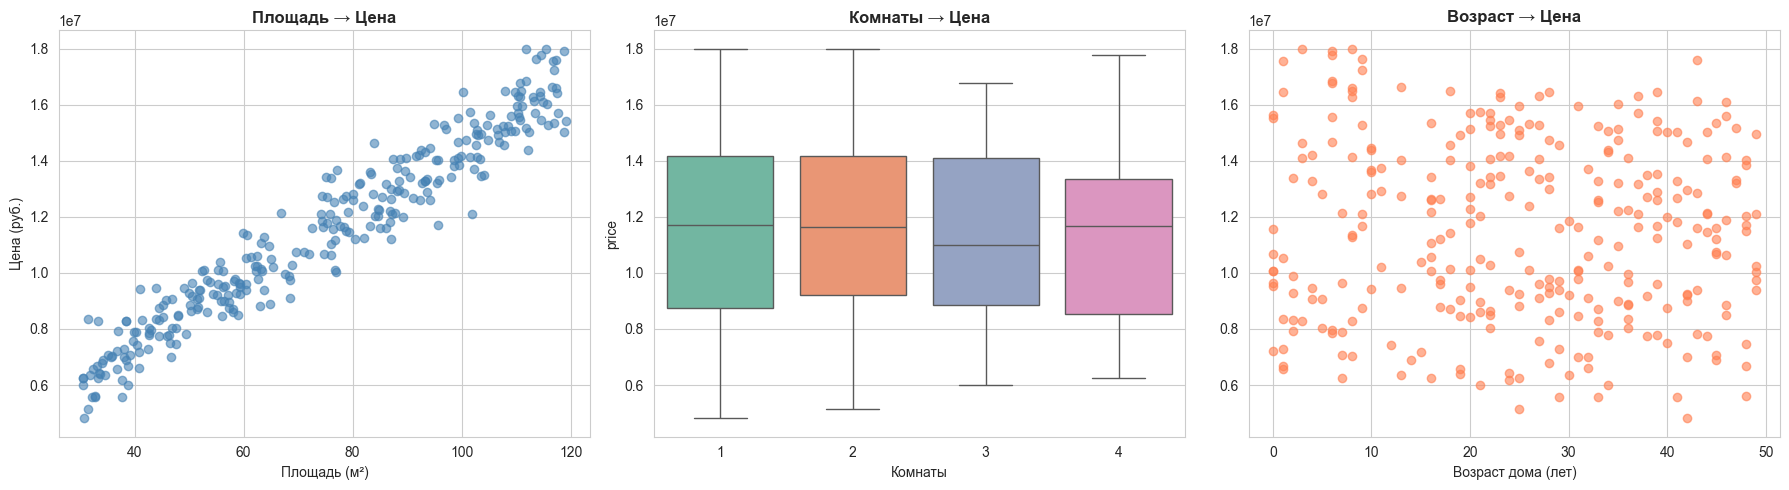

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(data['area'], data['price'], alpha=0.6, color='steelblue')
axes[0].set_xlabel('Площадь (м²)')
axes[0].set_ylabel('Цена (руб.)')
axes[0].set_title('Площадь → Цена', fontweight='bold')

sns.boxplot(data=data, x='rooms', y='price', ax=axes[1], hue='rooms', palette='Set2', legend=False)
axes[1].set_xlabel('Комнаты')
axes[1].set_title('Комнаты → Цена', fontweight='bold')

axes[2].scatter(data['age'], data['price'], alpha=0.6, color='coral')
axes[2].set_xlabel('Возраст дома (лет)')
axes[2].set_title('Возраст → Цена', fontweight='bold')

plt.tight_layout()
plt.show()

## 🤖 Обучаем линейную регрессию

In [19]:
X = data[['area', 'rooms', 'floor', 'age']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'📚 Train: {len(X_train)} записей')
print(f'🧪 Test: {len(X_test)} записей')

📚 Train: 240 записей
🧪 Test: 60 записей


In [20]:
# ⚠️ ПРОБЛЕМА: Линейные модели с регуляризацией требуют масштабирования (см. Урок 5)
# Используем Pipeline со StandardScaler для корректной работы Ridge и Lasso
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(X_train, y_train)

print('✅ Модель обучена (с использованием StandardScaler)!\n')

# Извлекаем коэффициенты из обученного пайплайна
lin_reg = model.named_steps['linearregression']
print('📊 Коэффициенты модели (на МАСШТАБИРОВАННЫХ данных):')
print(f'Intercept: {lin_reg.intercept_:,.0f} руб. (средняя цена при средних признаках)')
print()
for feature, coef in zip(X.columns, lin_reg.coef_):
    print(f'{feature}: {coef:,.0f} руб./ед. (изменение при сдвиге на 1 std. dev.)')

# Для интерпретации в исходных единицах лучше использовать модель БЕЗ масштабирования
# или рассчитать вручную, но для учебных целей покажем коэффициенты обычной модели
model_raw = LinearRegression().fit(X_train, y_train)

print('\n💡 Интерпретация (в реальных единицах - базовая цена и влияние признаков):')
print(f'   • Базовая цена (Intercept): {model_raw.intercept_:,.0f} руб.')
print(f'   • +1 м² → +{model_raw.coef_[0]:,.0f} руб.')
print(f'   • +1 комната → +{model_raw.coef_[1]:,.0f} руб.')
print(f'   • +1 этаж → +{model_raw.coef_[2]:,.0f} руб.')
print(f'   • +1 год возраста → {model_raw.coef_[3]:,.0f} руб. (дешевле!)')

✅ Модель обучена (с использованием StandardScaler)!

📊 Коэффициенты модели (на МАСШТАБИРОВАННЫХ данных):
Intercept: 11,468,684 руб. (средняя цена при средних признаках)

area: 3,154,788 руб./ед. (изменение при сдвиге на 1 std. dev.)
rooms: 304,531 руб./ед. (изменение при сдвиге на 1 std. dev.)
floor: 339,095 руб./ед. (изменение при сдвиге на 1 std. dev.)
age: -434,810 руб./ед. (изменение при сдвиге на 1 std. dev.)

💡 Интерпретация (в реальных единицах - базовая цена и влияние признаков):
   • Базовая цена (Intercept): 2,228,243 руб.
   • +1 м² → +118,162 руб.
   • +1 комната → +308,106 руб.
   • +1 этаж → +49,291 руб.
   • +1 год возраста → -31,446 руб. (дешевле!)


## 📊 Предсказания модели

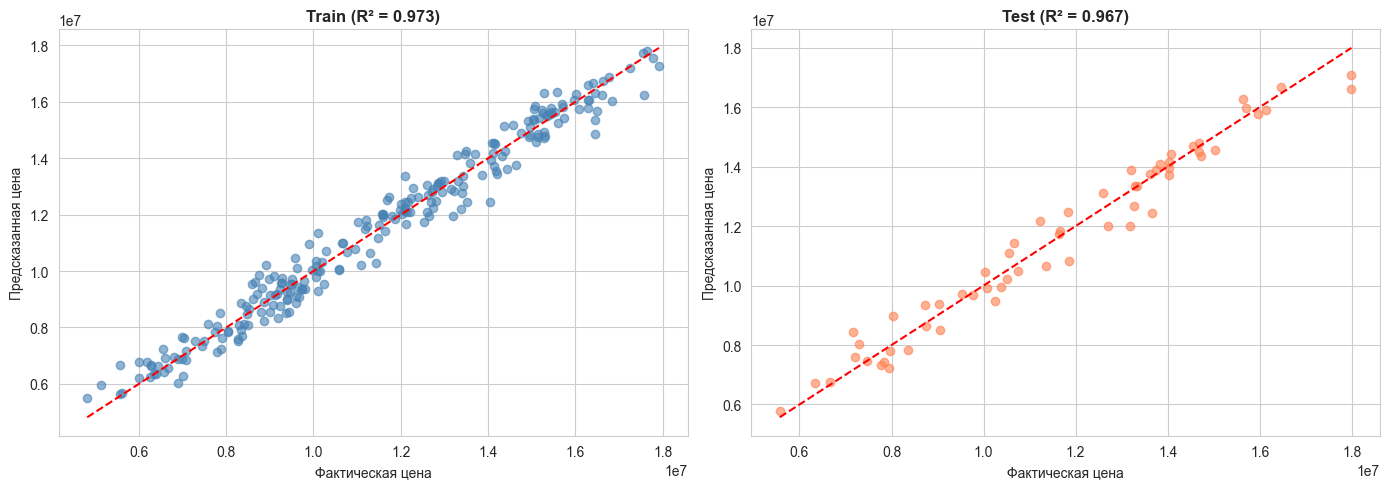

In [21]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_pred_train, alpha=0.6, color='steelblue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title(f'Train (R² = {r2_score(y_train, y_pred_train):.3f})', fontweight='bold')

axes[1].scatter(y_test, y_pred_test, alpha=0.6, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Фактическая цена')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title(f'Test (R² = {r2_score(y_test, y_pred_test):.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

## 📈 Метрики качества

In [22]:
def print_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'📊 Метрики для {name}:')
    print(f'   MSE:  {mse:,.0f}')
    print(f'   RMSE: {rmse:,.0f} руб.')
    print(f'   MAE:  {mae:,.0f} руб.')
    print(f'   R²:   {r2:.4f} ({r2*100:.1f}%)')
    print()

print_metrics(y_train, y_pred_train, 'Train')
print_metrics(y_test, y_pred_test, 'Test')

📊 Метрики для Train:
   MSE:  281,502,887,188
   RMSE: 530,568 руб.
   MAE:  421,996 руб.
   R²:   0.9728 (97.3%)

📊 Метрики для Test:
   MSE:  317,502,625,262
   RMSE: 563,474 руб.
   MAE:  450,953 руб.
   R²:   0.9670 (96.7%)



## 📉 Анализ остатков (Residuals)

**Остатки** — это разница между фактом и предсказанием. В идеальной модели они должны быть распределены случайно вокруг 0.

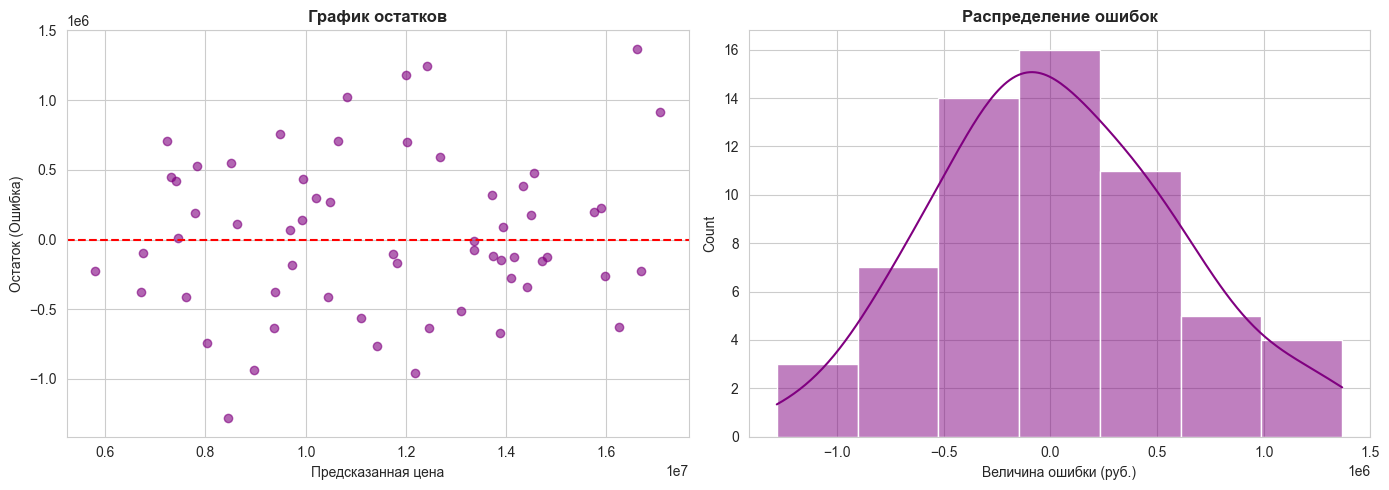

💡 Идеально: ошибки распределены нормально вокруг 0 без явных паттернов.


In [23]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot остатков
axes[0].scatter(y_pred_test, residuals, alpha=0.6, color='purple')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Предсказанная цена')
axes[0].set_ylabel('Остаток (Ошибка)')
axes[0].set_title('График остатков', fontweight='bold')

# Гистограмма остатков
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Распределение ошибок', fontweight='bold')
axes[1].set_xlabel('Величина ошибки (руб.)')

plt.tight_layout()
plt.show()

print('💡 Идеально: ошибки распределены нормально вокруг 0 без явных паттернов.')

## 🎯 Пример предсказания для новой квартиры

In [24]:
new_apartments = pd.DataFrame({
    'area': [45, 80, 120],
    'rooms': [1, 2, 4],
    'floor': [5, 15, 20],
    'age': [10, 5, 0]
})

predictions = model.predict(new_apartments)

result = new_apartments.copy()
result['predicted_price'] = predictions.round(0)
result['predicted_price_mln'] = (predictions / 1_000_000).round(2)

print('🔮 Предсказания для новых квартир:\n')
display(result)

🔮 Предсказания для новых квартир:



,area,rooms,floor,age,predicted_price,predicted_price_mln
0,45,1,5,10,7785646.0,7.79
1,80,2,15,5,12879573.0,12.88
2,120,4,20,0,18625963.0,18.63


## ⚠️ Регуляризация: Ridge и Lasso

In [25]:
# ВАЖНО: Регуляризация ВСЕГДА требует масштабирования!
models = {
    'Linear': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge (α=1)': make_pipeline(StandardScaler(), Ridge(alpha=1)),
    'Ridge (α=100)': make_pipeline(StandardScaler(), Ridge(alpha=100)),
    'Lasso (α=1000)': make_pipeline(StandardScaler(), Lasso(alpha=1000))
}

results = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    train_r2 = r2_score(y_train, mdl.predict(X_train))
    test_r2 = r2_score(y_test, mdl.predict(X_test))
    results.append({
        'Модель': name,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'Разница': round(train_r2 - test_r2, 4)
    })

comparison_df = pd.DataFrame(results).set_index('Модель')
display(comparison_df)

,Train R²,Test R²,Разница
Модель,,,
Linear,0.9728,0.9670,0.0058
Ridge (α=1),0.9728,0.9669,0.0059
Ridge (α=100),0.8851,0.8769,0.0082
Lasso (α=1000),0.9728,0.9670,0.0058


### 📊 Сравнение методов регуляризации

| Метод | Штраф | Особенность | Когда использовать |
|-------|-------|-------------|--------------------|
| **Linear** | Нет | Без ограничений | Базовая модель |
| **Ridge (L2)** | Квадрат весов | Уменьшает все веса, не зануляя их | Много мелких признаков |
| **Lasso (L1)** | Модуль весов | Может **занулять** веса (отбор признаков) | Много лишних признаков |

💡 **Регуляризация** помогает бороться с переобучением, когда модель слишком сильно подстраивается под обучающие данные.

## 💼 Бизнес-кейс: Прогноз цен в агентстве недвижимости

**Задача**: Автоматизировать оценку стоимости квартир для сайта объявлений.

**Результаты внедрения**:
- **Точность**: Средняя ошибка (MAE) снизилась с 1.2 млн руб. (экспертная оценка) до 450 тыс. руб.
- **Скорость**: Мгновенная оценка вместо 24 часов ожидания звонка риелтора.
- **Прозрачность**: Теперь клиент видит, за что именно он переплачивает (этаж, площадь, ремонт).

**Эффект**: Количество новых объявлений выросло на 30%, так как пользователям проще оценить свою недвижимость.

## 📝 Чек-лист линейной регрессии

- [ ] Проверить линейную связь (scatter plots)
- [ ] Разделить train/test
- [ ] Обучить модель
- [ ] Проверить анализ остатков (Residuals)
- [ ] Проверить метрики (R², RMSE, MAE)
- [ ] Интерпретировать коэффициенты
- [ ] Проверить переобучение (train vs test)

---

## 🎓 Практическое задание

1. Найдите датасет с непрерывной целевой переменной
2. Постройте линейную регрессию
3. Интерпретируйте коэффициенты
4. Попробуйте Ridge/Lasso

---

## ➡️ Что дальше?

В следующем уроке: **Логистическая регрессия** для классификации!